[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaCoZu/Python/blob/a8908df8ff79048cb317a168f4ae6733814b0e62/NOTEBOOKS/pandas/Statistics_from_observation_to%20_model.ipynb)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression

In [18]:
sns.set_theme(style="white")

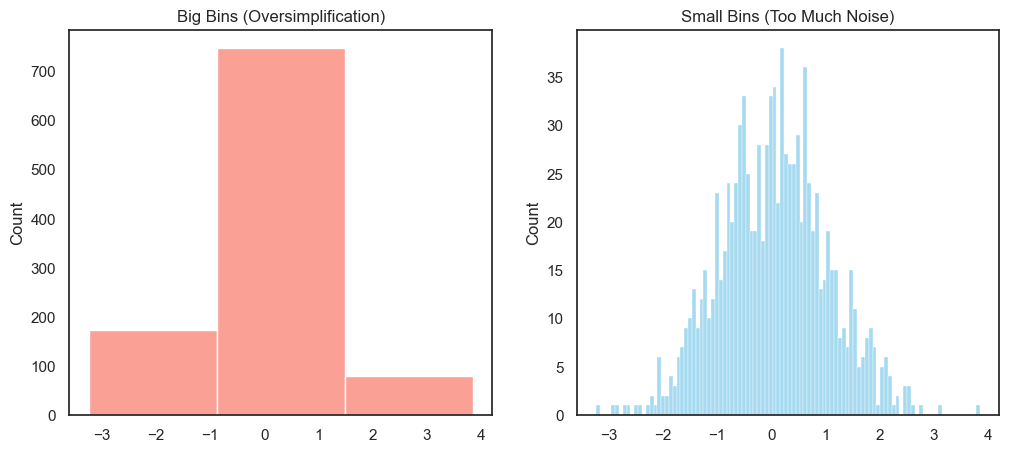

In [19]:
data = np.random.normal(0, 1, 1000)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Under-fitting / High Bias
sns.histplot(data, bins=3, ax=axes[0], color='salmon')
axes[0].set_title("Big Bins (Oversimplification)")

# Over-fitting / High Variance
sns.histplot(data, bins=100, ax=axes[1], color='skyblue')
axes[1].set_title("Small Bins (Too Much Noise)")

plt.show()

Mean: 0.52
Median: 0.55
Variance: 7.27
Standard Deviation: 2.70
Minimum: -5.24
Maximum: 5.63
Range: 10.87
Q1: -1.99
Q3: 3.03
IQR: 5.02


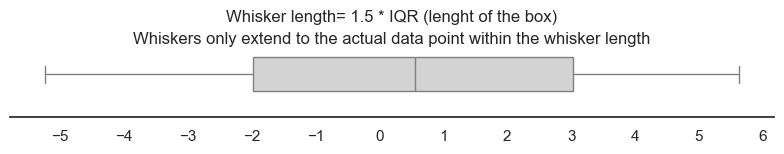

In [20]:
np.random.seed(42)
data = np.concatenate([np.random.normal(-2, 1, 500), np.random.normal(3, 1, 500)])

print(f"Mean: {np.mean(data):.2f}")
print(f"Median: {np.median(data):.2f}")
print(f"Variance: {np.var(data):.2f}")
print(f"Standard Deviation: {np.std(data):.2f}")
print(f"Minimum: {np.min(data):.2f}")
print(f"Maximum: {np.max(data):.2f}")
print(f"Range: {np.max(data) - np.min(data):.2f}")
print(f"Q1: {np.percentile(data, 25):.2f}")
print(f"Q3: {np.percentile(data, 75):.2f}")
print(f"IQR: {np.percentile(data, 75) - np.percentile(data, 25):.2f}")

plt.figure(figsize=(8, 2))
ax = sns.boxplot(x=data, color='lightgray', whis=1.5, width=0.4)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
sns.despine(left=True, top=True, right=True)
plt.title("Whisker length= 1.5 * IQR (lenght of the box)", fontsize=12, pad=10, y=0.95)
plt.suptitle("Whiskers only extend to the actual data point within the whisker length", fontsize=12, y=0.65)
plt.tight_layout()
plt.show()

# Skewness

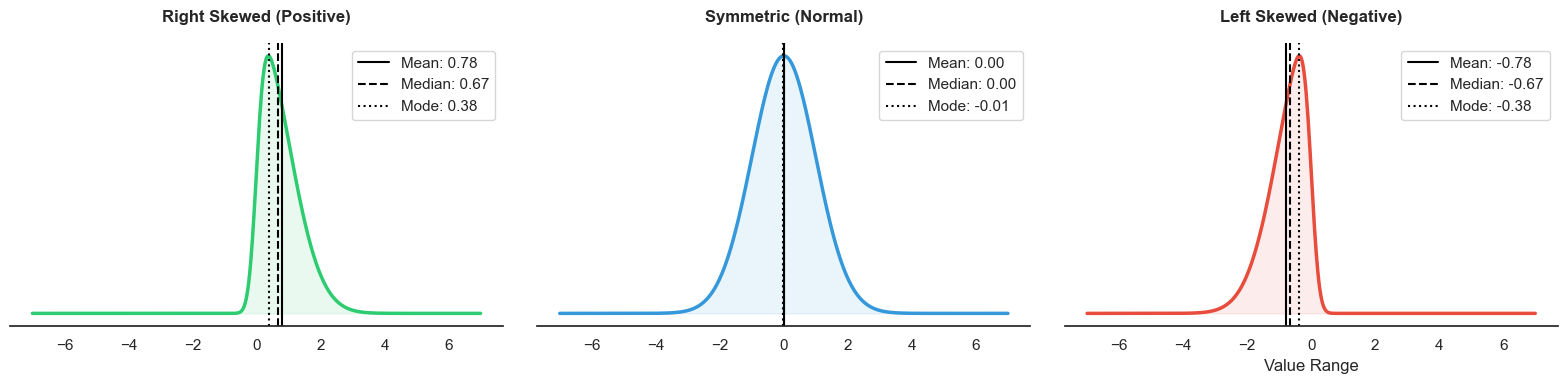

In [21]:
x = np.linspace(-7, 7, 500)
skew_params = [5, 0, -5]  # Right, Symmetric, Left
labels = ['Right Skewed (Positive)', 'Symmetric (Normal)', 'Left Skewed (Negative)']
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for i, alpha in enumerate(skew_params):
    pdf = stats.skewnorm.pdf(x, alpha)

    mean_val = stats.skewnorm.mean(alpha)
    median_val = stats.skewnorm.ppf(0.5, alpha)
    mode_val = x[np.argmax(pdf)]

    axes[i].plot(x, pdf, color=colors[i], lw=2.5)
    axes[i].fill_between(x, pdf, color=colors[i], alpha=0.1)

    axes[i].axvline(mean_val, color='black', linestyle='-', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='black', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].axvline(mode_val, color='black', linestyle=':', label=f'Mode: {mode_val:.2f}')

    axes[i].set_title(labels[i], fontweight='bold', pad=15)
    axes[i].legend(loc='upper right', frameon=True)
    axes[i].set_yticks([])
    sns.despine(ax=axes[i], left=True)

plt.xlabel("Value Range")
plt.tight_layout()
plt.show()

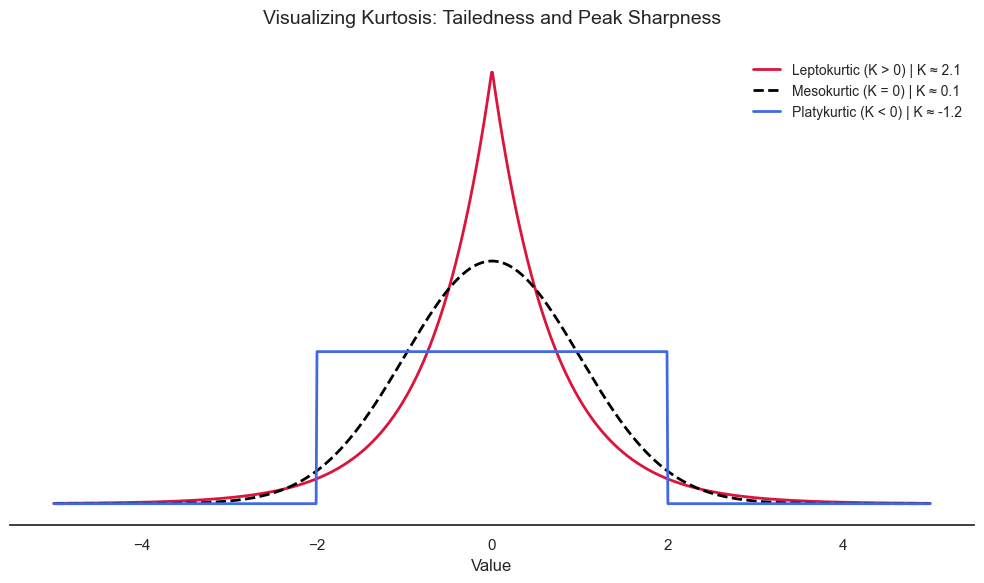

In [22]:


x = np.linspace(-5, 5, 1000)

lepto = stats.laplace.pdf(x, loc=0, scale=0.7)
k_lepto = stats.kurtosis(stats.laplace.rvs(size=1000))

meso = stats.norm.pdf(x, loc=0, scale=1)
k_meso = stats.kurtosis(stats.norm.rvs(size=1000))

platy = np.where((x >= -2) & (x <= 2), 0.25, 0)
k_platy = -1.2

plt.figure(figsize=(10, 6))

plt.plot(x, lepto, label=f'Leptokurtic (K > 0) | K ≈ {k_lepto:.1f}', color='crimson', lw=2)
plt.plot(x, meso, label=f'Mesokurtic (K = 0) | K ≈ {k_meso:.1f}', color='black', lw=2, linestyle='--')
plt.plot(x, platy, label=f'Platykurtic (K < 0) | K ≈ {k_platy:.1f}', color='royalblue', lw=2)

sns.despine(left=True, top=True, right=True)
plt.title("Visualizing Kurtosis: Tailedness and Peak Sharpness", fontsize=14, pad=20)
plt.yticks([])
plt.legend(frameon=False, fontsize=10)
plt.xlabel("Value")

plt.tight_layout()
plt.show()

# Normal- and t-Distributions

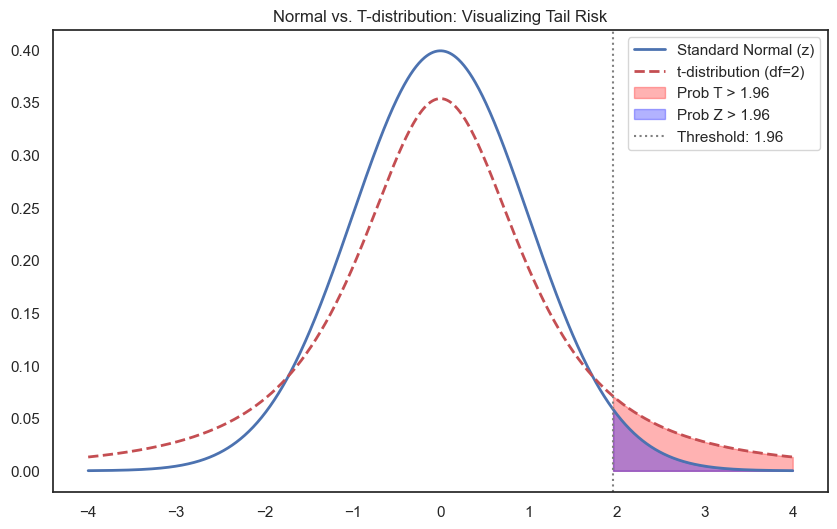

Prob. of Z > 1.96: 0.0250  (Area under blue): 97.5% chance of being above 1.96
Prob. of T (df=2) > 1.96: 0.0945 (Area under red)


In [23]:
x = np.linspace(-4, 4, 1000)
z_pdf = stats.norm.pdf(x)
t_pdf = stats.t.pdf(x, df=2)

plt.figure(figsize=(10, 6))
plt.plot(x, z_pdf, 'b-', lw=2, label='Standard Normal (z)')
plt.plot(x, t_pdf, 'r--', lw=2, label='t-distribution (df=2)')

# Shading the area where x > 1.96
x_shade = np.linspace(1.96, 4, 100)
plt.fill_between(x_shade, stats.t.pdf(x_shade, df=2), color='red', alpha=0.3, label='Prob T > 1.96')
plt.fill_between(x_shade, stats.norm.pdf(x_shade), color='blue', alpha=0.3, label='Prob Z > 1.96')

plt.axvline(1.96, color='gray', linestyle=':', label='Threshold: 1.96')
plt.title("Normal vs. T-distribution: Visualizing Tail Risk")
plt.legend()
plt.show()

print(f"Prob. of Z > 1.96: {1 - stats.norm.cdf(1.96):.4f}  (Area under blue): {stats.norm.cdf(1.96)*100:.1f}% chance of being above 1.96")
print(f"Prob. of T (df=2) > 1.96: {1 - stats.t.cdf(1.96, df=2):.4f} (Area under red)")

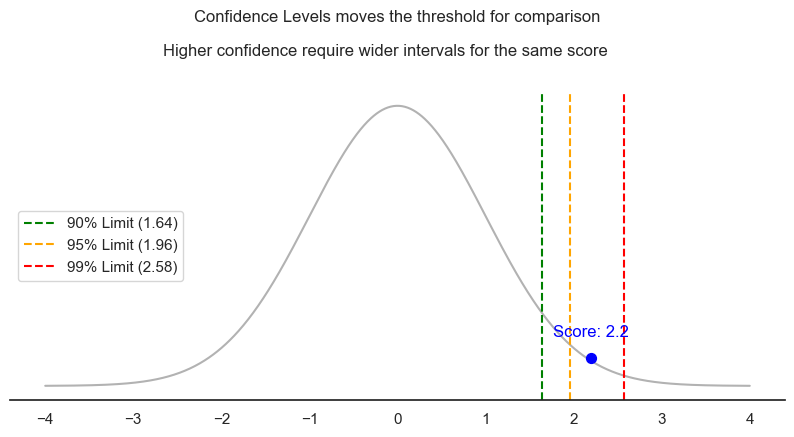

In [24]:
my_score = 2.2

conf_90 = stats.norm.ppf(0.95) # ~1.64
conf_95 = stats.norm.ppf(0.975) # ~1.96
conf_99 = stats.norm.ppf(0.995) # ~2.58

plt.figure(figsize=(10, 4))
x = np.linspace(-4, 4, 1000)
plt.plot(x, stats.norm.pdf(x), color='black', alpha=0.3)

plt.axvline(conf_90, color='green', linestyle='--', label=f'90% Limit ({conf_90:.2f})') # type: ignore
plt.axvline(conf_95, color='orange', linestyle='--', label=f'95% Limit ({conf_95:.2f})') # type: ignore
plt.axvline(conf_99, color='red', linestyle='--', label=f'99% Limit ({conf_99:.2f})') # type: ignore

plt.scatter(my_score, 0.04, color='blue', s=50, zorder=5)
plt.annotate(f"Score: {my_score}", (my_score, 0.07), ha='center',  color='blue')

plt.title("Confidence Levels moves the threshold for comparison", y=1.2, fontsize=12)
plt.suptitle("Higher confidence require wider intervals for the same score", y=1, fontsize=12 )
plt.legend(loc='center left')
sns.despine(left=True)
plt.yticks([])
plt.show()

# Confidence Intervals: 
## intervals that contain the true mean 

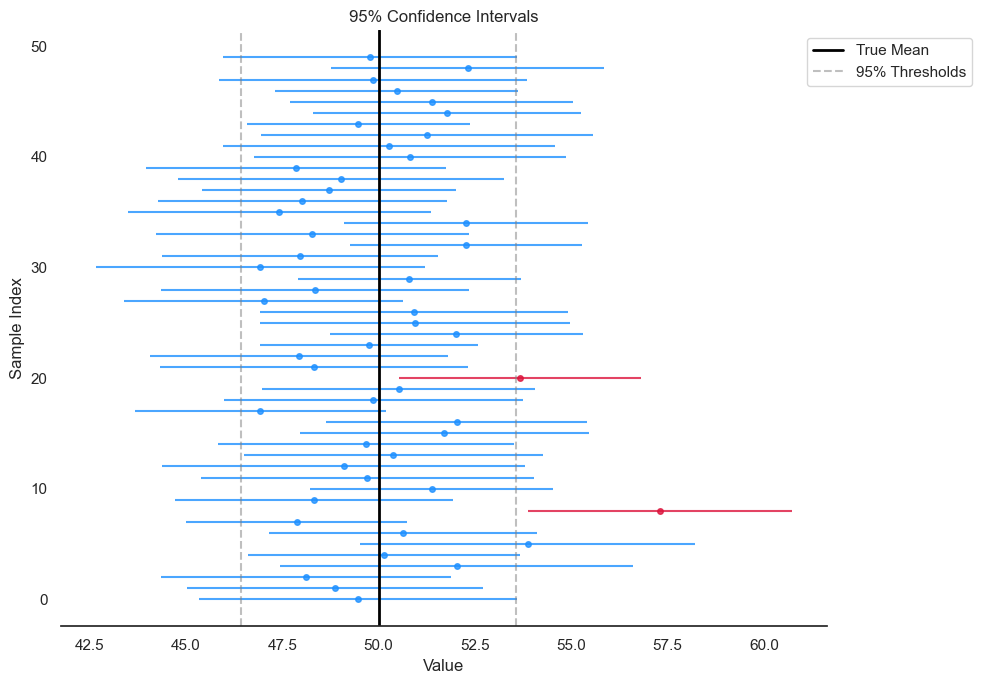

In [25]:
# RUN THIS CELL MULTIPLE TIMES TO SEE DIFFERENT SAMPLES AND THEIR CIs

pop_mean, pop_std, n = 50, 10, 30
sem = pop_std / np.sqrt(n)
z_crit = stats.norm.ppf(0.975)
lower_thresh, upper_thresh = pop_mean - (z_crit * sem), pop_mean + (z_crit * sem)

samples = [np.random.choice(np.random.normal(pop_mean, pop_std, 10000), n) for _ in range(50)]

plt.figure(figsize=(10, 7))

for i, s in enumerate(samples):
    m = np.mean(s)
    ci = stats.t.interval(0.95, len(s)-1, loc=m, scale=stats.sem(s))
    color = 'dodgerblue' if ci[0] < pop_mean < ci[1] else 'crimson'
    plt.errorbar(m, i, xerr=((ci[1]-ci[0])/2), fmt='o', color=color, alpha=0.8, markersize=4)

# Lines
plt.axvline(pop_mean, color='black', linewidth=2, label='True Mean')
plt.axvline(lower_thresh, color='gray', linestyle='--', alpha=0.5, label='95% Thresholds')
plt.axvline(upper_thresh, color='gray', linestyle='--', alpha=0.5)

sns.despine(left=True, top=True, right=True)

plt.title("95% Confidence Intervals")
plt.xlabel("Value")
plt.ylabel("Sample Index")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

# Kernel Density Estimation (KDE)
## from relative frequency to a smooth probability curve

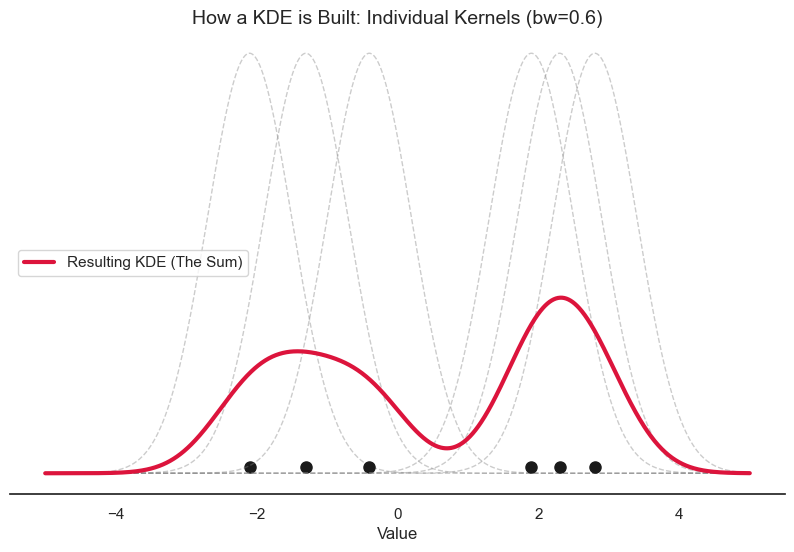

In [26]:
# CHANGE BANDWIDTH TO SEE DIFFERENT EFFECTS

bandwidth = 0.6

data = np.array([-2.1, -1.3, -0.4, 1.9, 2.3, 2.8])
x_axis = np.linspace(-5, 5, 1000)


plt.figure(figsize=(10, 6))

kernels = []
for x_point in data:
    kernel = stats.norm(x_point, bandwidth).pdf(x_axis) # type: ignore
    kernels.append(kernel)

    plt.plot(x_axis, kernel, color='gray', linestyle='--', alpha=0.4, lw=1)
    plt.plot(x_point, 0.01, 'ko', markersize=8)

sum_of_kernels = np.sum(kernels, axis=0) / len(data)

plt.plot(x_axis, sum_of_kernels, color='crimson', lw=3, label='Resulting KDE (The Sum)')

sns.despine(left=True, top=True, right=True)
plt.yticks([])
plt.title(f"How a KDE is Built: Individual Kernels (bw={bandwidth})", fontsize=14)
plt.legend()
plt.xlabel("Value")
plt.show()

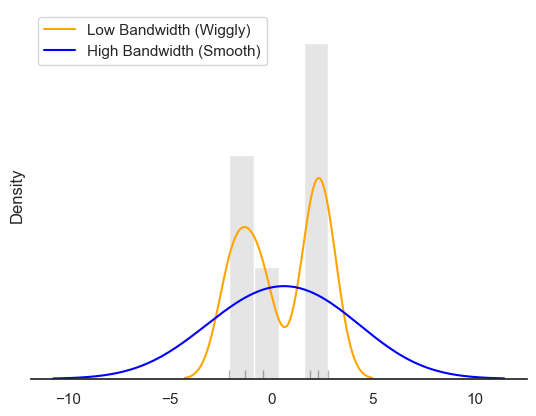

In [27]:
sns.kdeplot(data, bw_adjust=0.5, label="Low Bandwidth (Wiggly)", color="orange")
sns.kdeplot(data, bw_adjust=2, label="High Bandwidth (Smooth)", color="blue")

sns.rugplot(data, color="black", alpha=0.3)
sns.histplot(data, stat="density", alpha=0.2, color="gray", edgecolor=None)

sns.despine(left=True, top=True, right=True)
plt.yticks([])
plt.legend()
plt.show()

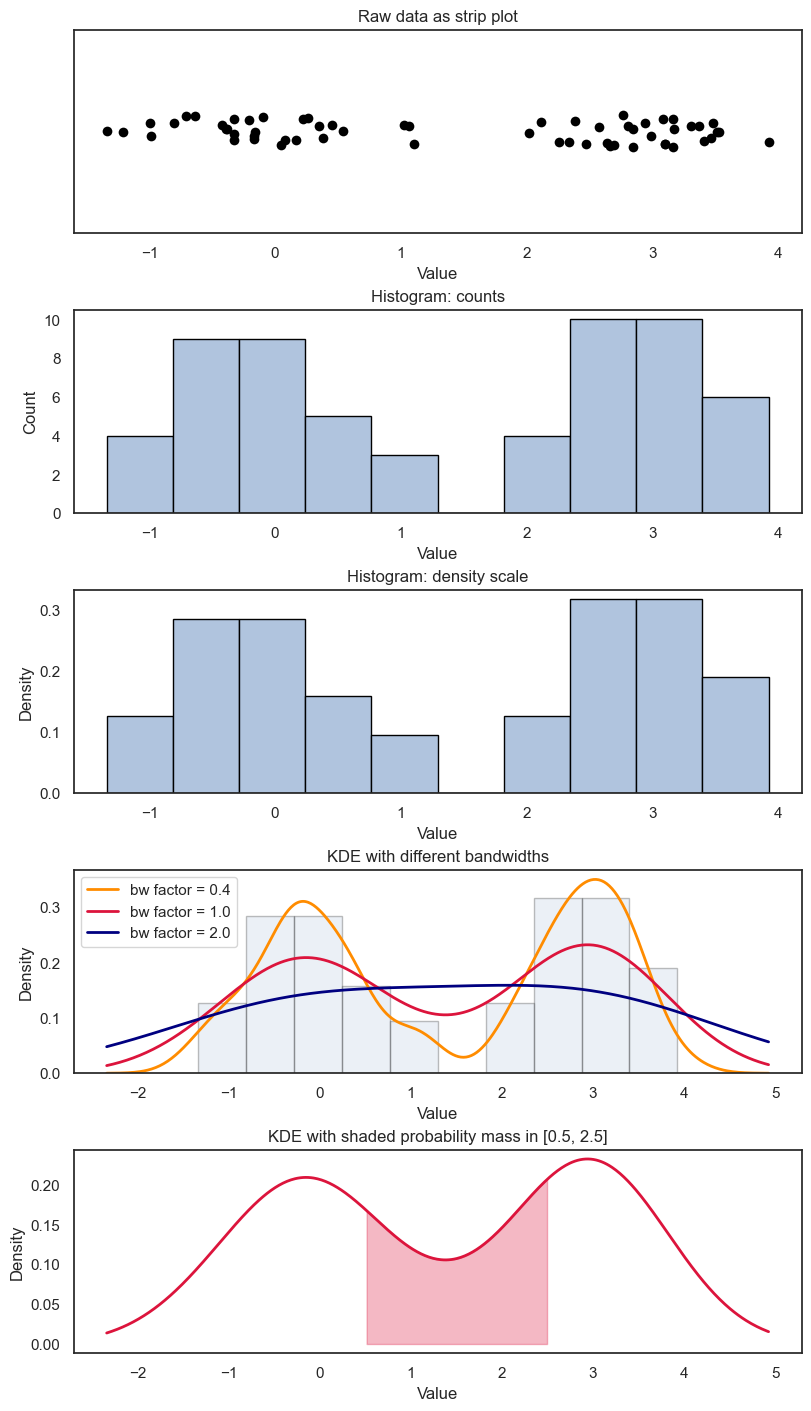

In [28]:
np.random.seed(42)

x = np.concatenate([
    np.random.normal(loc=0.0, scale=0.7, size=30),
    np.random.normal(loc=3.0, scale=0.5, size=30)
])

grid = np.linspace(x.min() - 1, x.max() + 1, 500)

def kde_with_bandwidth(x, grid, bw_factor):
    kde = stats.gaussian_kde(x)
    kde.set_bandwidth(bw_method=kde.factor * bw_factor)
    return kde(grid)

fig, axes = plt.subplots(5, 1, figsize=(8, 14), constrained_layout=True)

sns.stripplot(x=x, orient="h", jitter=0.08, size=7, color="black", ax=axes[0])
axes[0].set_title("Raw data as strip plot")
axes[0].set_yticks([])
axes[0].set_xlabel("Value")

axes[1].hist(x, bins=10, edgecolor="black", color="lightsteelblue")
axes[1].set_title("Histogram: counts")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

axes[2].hist(x, bins=10, density=True, edgecolor="black", color="lightsteelblue")
axes[2].set_title("Histogram: density scale")
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Density")

bandwidths = [0.4, 1.0, 2.0]
colors = ["darkorange", "crimson", "navy"]

for bw, c in zip(bandwidths, colors):
    y = kde_with_bandwidth(x, grid, bw)
    axes[3].plot(grid, y, color=c, linewidth=2, label=f"bw factor = {bw}")

axes[3].hist(x, bins=10, density=True, alpha=0.25, edgecolor="black", color="lightsteelblue")
axes[3].set_title("KDE with different bandwidths")
axes[3].set_xlabel("Value")
axes[3].set_ylabel("Density")
axes[3].legend()

bw = 1.0
y = kde_with_bandwidth(x, grid, bw)
a, b = 0.5, 2.5
mask = (grid >= a) & (grid <= b)

axes[4].plot(grid, y, color="crimson", linewidth=2)
axes[4].fill_between(grid[mask], y[mask], color="crimson", alpha=0.3)
axes[4].set_title(f"KDE with shaded probability mass in [{a}, {b}]")
axes[4].set_xlabel("Value")
axes[4].set_ylabel("Density")

plt.show()

# Modeling

#### Extrapolation

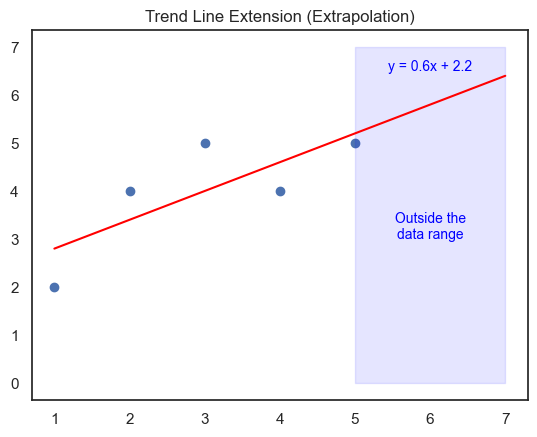

In [29]:
x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 4, 5, 4, 5])
model = LinearRegression().fit(x, y)

x_future = np.array([[6], [7]])
y_pred = model.predict(x_future)

plt.scatter(x, y)
plt.plot(np.vstack([x, x_future]), model.predict(np.vstack([x, x_future])), color='red')
plt.fill_between(np.linspace(5, 7, 100), y1=0, y2=7, color='blue', alpha=0.1)
plt.title("Trend Line Extension (Extrapolation)")
plt.annotate("Outside the\ndata range", (6, 3), color='blue', fontsize=10, ha='center')
plt.annotate(f"y = {model.coef_[0]:.1f}x + {model.intercept_:.1f}", (6, 6.5), color='blue', fontsize=10, ha='center')
plt.show()

#### Time Series Decomposition

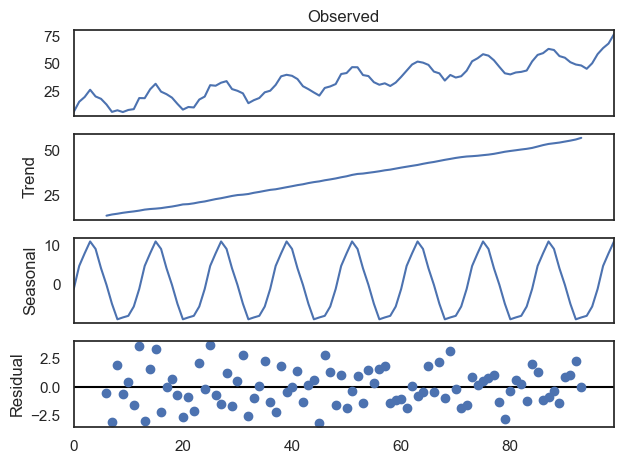

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

time = np.arange(100)
series = 10 + 0.5 * time + 10 * np.sin(2 * np.pi * time / 12) + np.random.normal(0, 2, 100)

result = seasonal_decompose(series, model='additive', period=12)
result.plot()
plt.show()

#### Neural Network
A neural network has an input layer hidden layers and an output layer.

Here we have two hidden layers with 100 neurons each. 

The input layer connects 1:100 neurons, the two hidden layers connect 100:100 neurons, and the second layer connects 100:1 neurons.

Therefor we have 1*100 + 100*100 + 100*1 = 10200 connections or weights.

Compare this to the 2 parameters we have in a simple regression, and you get the idea of why we talk of an inexplicable black box.



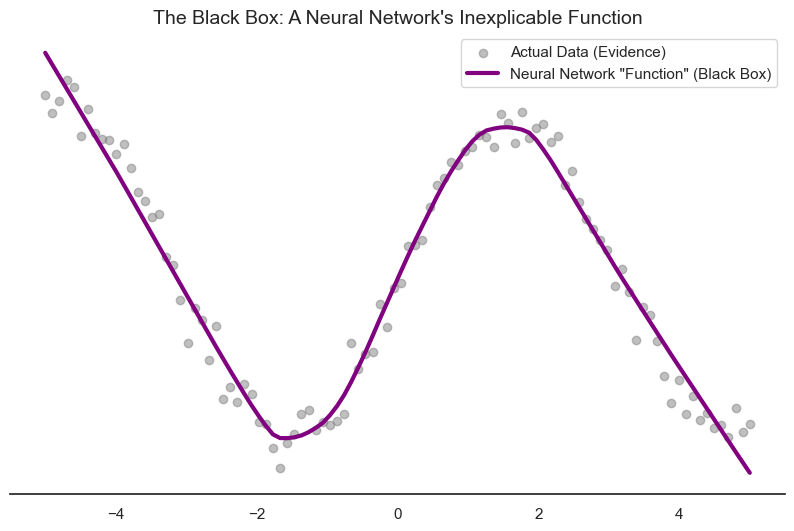

Number of layers: 4
Number of internal weights: 10200

First 5 weights of the first layer (just a tiny piece of the 'logic'):
[[-0.02516532  0.06678526 -0.22250176 -0.08613342  0.04514356]]

First 5 weights of the first two neurons in the second layer:
[[-0.04149016 -0.02531919  0.05328444  0.05752395 -0.03611829]
 [ 0.01452699  0.02387121  0.19695561 -0.12241264  0.06954599]]

There're 100 neurons in the second layer and each neuron has 100 weights.




In [31]:
from sklearn.neural_network import MLPRegressor

np.random.seed(0)
X = np.linspace(-5, 5, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

mlp = MLPRegressor(hidden_layer_sizes=(100, 100), activation='relu', max_iter=2000)
mlp.fit(X, y)

y_pred = mlp.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Actual Data (Evidence)')
plt.plot(X, y_pred, color='purple', lw=3, label='Neural Network "Function" (Black Box)')

sns.despine(left=True, bottom=False)
plt.title("The Black Box: A Neural Network's Inexplicable Function", fontsize=14)
plt.yticks([])
plt.legend()
plt.show()

print(f"Number of layers: {mlp.n_layers_}")
print(f"Number of internal weights: {sum(w.size for w in mlp.coefs_)}")
print("\nFirst 5 weights of the first layer (just a tiny piece of the 'logic'):")
print(mlp.coefs_[0][:, :5])
print("\nFirst 5 weights of the first two neurons in the second layer:")
print(mlp.coefs_[1][:2, :5])
print("\nThere're 100 neurons in the second layer and each neuron has 100 weights.")
print("\n")